In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import *
from matplotlib.animation import FuncAnimation
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, init_vprinting
from scipy.optimize import least_squares
from scipy.optimize import fsolve

dict_items([('P1', d*N.y + la*E.x + 0.024*G.x + 0.01*G.y), ('P2', d*N.y + la*E.x + 0.022*G.x), ('P3', d*N.y + la*E.x + 0.024*G.x - 0.01*G.y)])

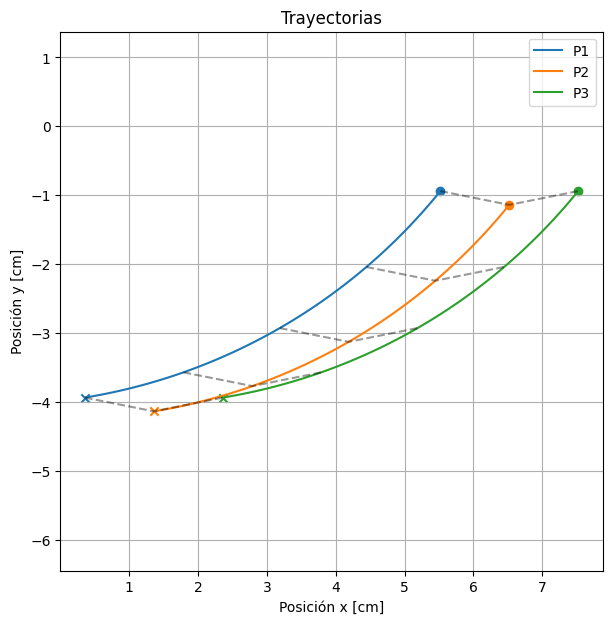

In [13]:
#MECANISMO 3
theta,alpha,beta = dynamicsymbols("theta alpha beta")
thetadot = theta.diff()
alphadot = alpha.diff()
betadot = beta.diff()
d,lm,la,lv = symbols("d lm la lv")

#Sistemas de referencia 
N = ReferenceFrame("N")
M = N.orientnew("M","Axis",(alpha,N.z))
E = N.orientnew("E","Axis",(theta,N.z)) 
G = N.orientnew("G","Axis",(beta,N.z))

r_PA = lm*M.x
r_AS = lv*G.x
r_PH = d*N.y
r_HS = la*E.x


loop = r_PA + r_AS - r_PH - r_HS

eq_x = loop.dot(N.x)
eq_y = loop.dot(N.y)
eqlist =[eq_x,eq_y]
# Dimensiones del paralelogramo con theta y alpha iguales
params = {
    d:  0.0194,
    lm: 0.0839,
    la: 0.0839,
    lv: 0.0194
}

# Posición de S respecto a P
r_PS = r_PH + r_HS

# Distancia desde S hasta P2
l_punta_x = 0.022

# Separación lateral entre los extremos
ancho_punta = 0.020
l_punta_y = ancho_punta / 2

# Cuánto sobresalen P1 y P3 respecto a P2 en dirección G.x
h = 0.002  

r_PP2 = r_PS + l_punta_x*G.x

r_PP1 = r_PP2 + h*G.x + l_punta_y*G.y
r_PP3 = r_PP2 + h*G.x - l_punta_y*G.y


condiciones = {
    alpha: theta,
    beta: sp.pi/2
}

puntos = {
    "P1": r_PP1,
    "P2": r_PP2,
    "P3": r_PP3
}
display(puntos.items())
# Las posiciones ahora dependen únicamente de theta
points_func = {}

for nombre, vector in puntos.items():

    coordenada_x = vector.dot(N.x).subs(params).subs(condiciones)
    coordenada_y = vector.dot(N.y).subs(params).subs(condiciones)

    points_func[nombre] = sp.lambdify(theta,[coordenada_x, coordenada_y],"numpy")

# Recorrido del actuador
R = 0.0275
x_act = np.linspace(0, 0.020, 100)

theta0 = np.deg2rad(-39.01)
sentido = -1

trayectorias = {
    "P1": [],
    "P2": [],
    "P3": []
}

for x in x_act:

    theta_val = theta0 + sentido*x/R

    for nombre, funcion in points_func.items():
        posicion = funcion(theta_val)
        trayectorias[nombre].append(posicion)

# Gráfica de trayectorias
plt.figure(figsize=(7, 7))

for nombre in ["P1", "P2", "P3"]:

    trayectoria = np.array(trayectorias[nombre])

    linea, = plt.plot(
        trayectoria[:, 0]*100,
        trayectoria[:, 1]*100,
        label=nombre
    )

    # Inicio: círculo
    plt.scatter(
        trayectoria[0, 0]*100,
        trayectoria[0, 1]*100,
        color=linea.get_color(),
        marker="o"
    )

    # Final: equis
    plt.scatter(
        trayectoria[-1, 0]*100,
        trayectoria[-1, 1]*100,
        color=linea.get_color(),
        marker="x"
    )

plt.xlabel("Posición x [cm]")
plt.ylabel("Posición y [cm]")
plt.title("Trayectorias")
plt.axis("equal")
plt.grid()
plt.legend()
for i in [0, 25, 50, 75, 99]:

    posiciones = np.array([
        trayectorias["P1"][i],
        trayectorias["P2"][i],
        trayectorias["P3"][i]
    ])

    plt.plot(
        posiciones[:, 0]*100,
        posiciones[:, 1]*100,
        "k--",
        alpha=0.4
    )
plt.show()

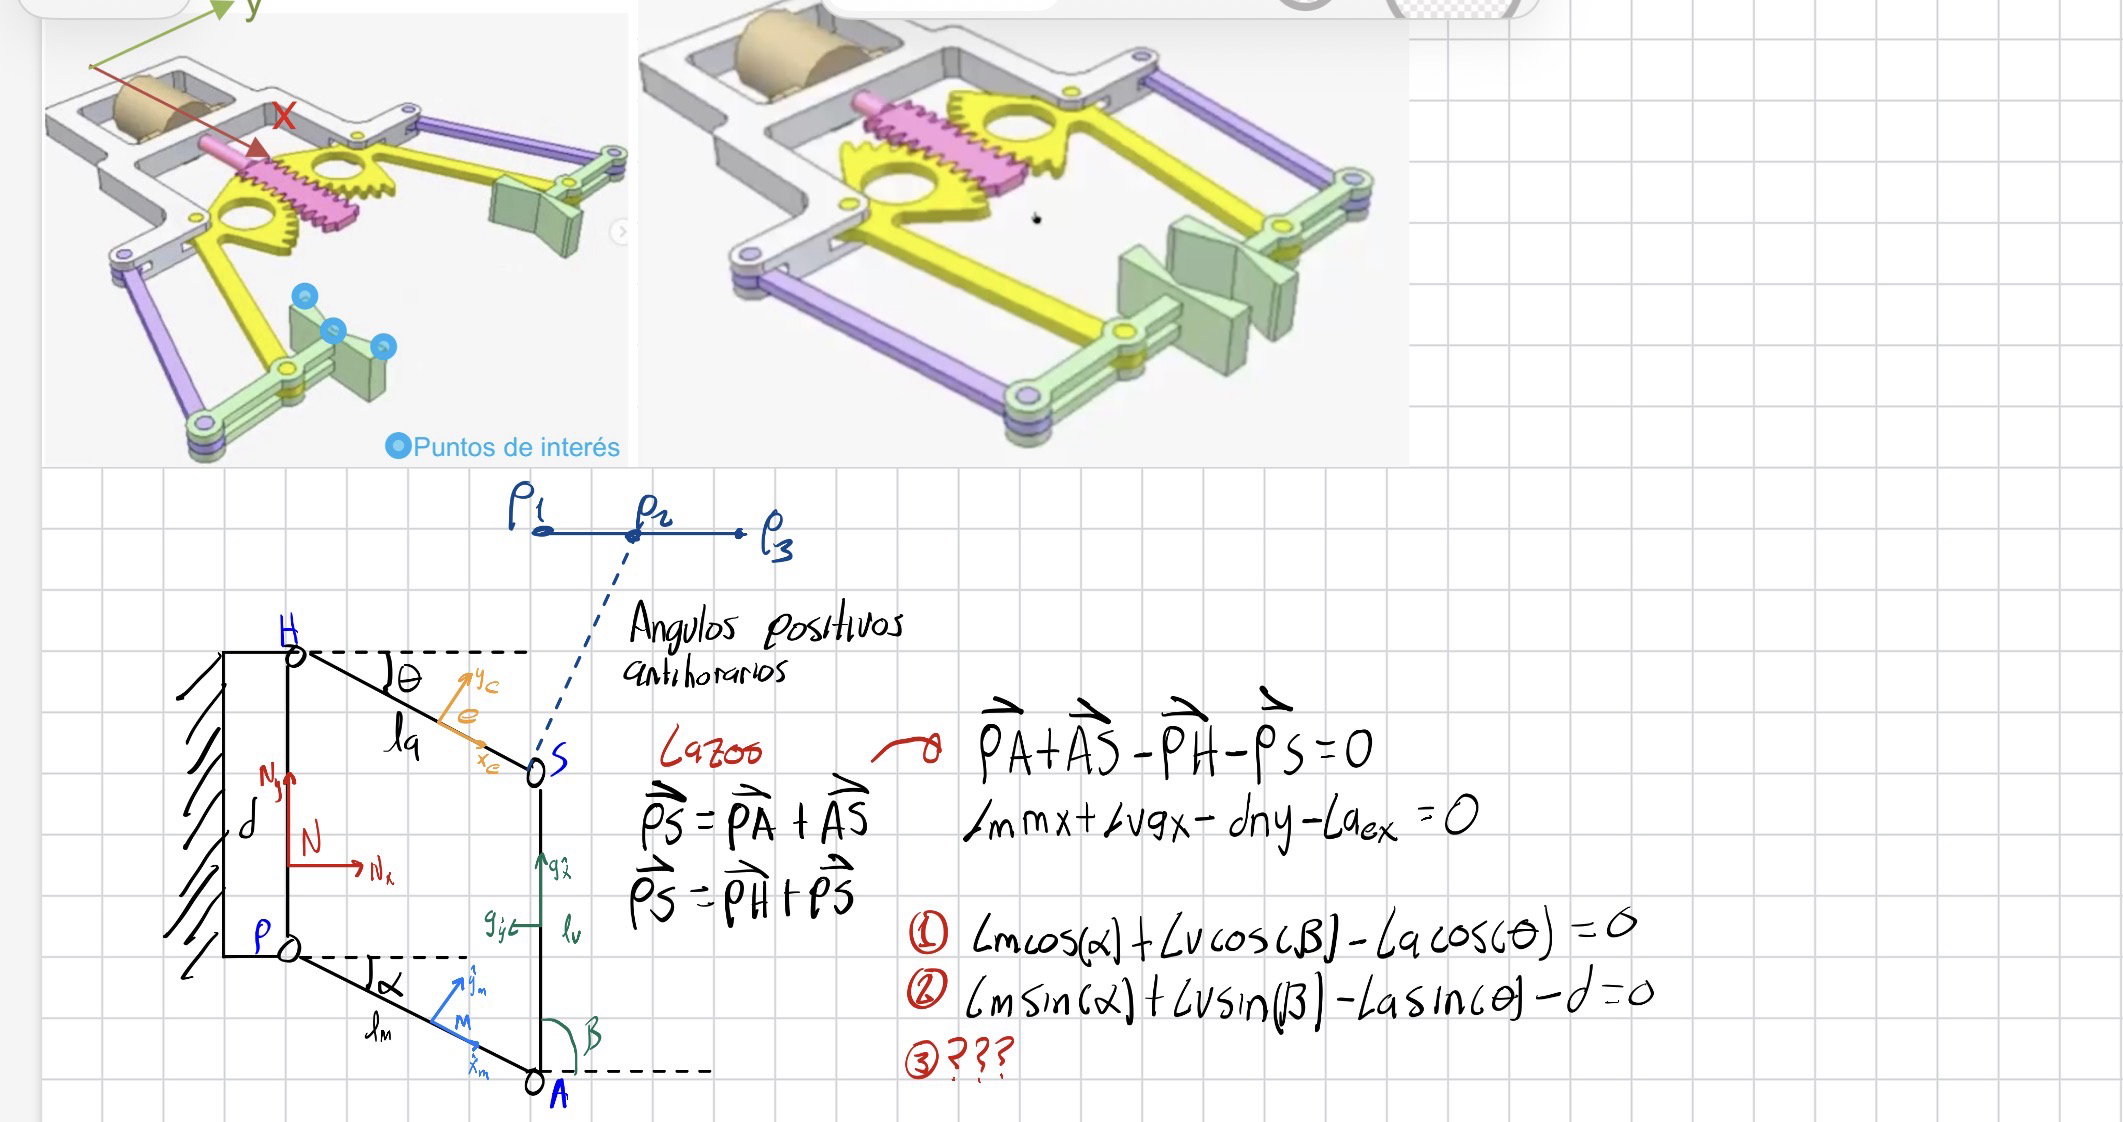